# Assignment 1

## Part I — Probability Theory & Derivations

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import gamma as gamma_func
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

---

## Q1. The Lognormal Distribution

### 1a. Derivation of the Mode

A random variable $X$ follows a lognormal distribution if $\ln X \sim \mathcal{N}(\mu, \sigma^2)$. 
The probability density function is

$$f_X(x) = \frac{1}{x \sigma \sqrt{2\pi}} \exp\!\left(-\frac{(\ln x - \mu)^2}{2\sigma^2}\right), \quad x > 0$$

The mode is the value of $x$ that maximises $f_X(x)$. We find it by setting $f'_X(x)=0$.

Consider
$$\ln f_X(x) = -\ln x - \ln(\sigma\sqrt{2\pi}) - \frac{(\ln x - \mu)^2}{2\sigma^2}.$$

If
$$\frac{d}{dx}\ln f_X(x) = -\frac{1}{x} - \frac{(\ln x - \mu)}{x\,\sigma^2} = 0,$$

we have

$$\sigma^2 + (\ln x - \mu) = 0 \quad\Rightarrow\quad \ln x = \mu - \sigma^2 \quad\Rightarrow\quad x = e^{\mu - \sigma^2}.$$

Since $f_X(x) \to 0$ as $x\to 0^+$ and $x\to\infty$, and $f_X > 0$ in between, we conclude that
$$\boxed{\text{Mode} = e^{\mu - \sigma^2}}$$

### 1b. Visualization ($\mu=0$, $\sigma=1$)

![Lognormal Distribution](Figure_1.png)

---

## Q2. Elicitability of the Quantile

Claim. The quantile functional $T(F) = q_\alpha(F) = F^{-1}(\alpha)$ is elicitable.

Definition. A functional $T$ is *elicitable* if there exists a loss function $S(x, y)$ such that:

$$T(F) = \arg\min_{y} \; \mathbb{E}_F\!\big[S(X, y)\big]$$

Proof. We use the pinball loss:

$$S_\alpha(x, y) = \bigl(\alpha - 1_{\{x < y\}}\bigr)(x - y) = \begin{cases} \alpha\,(x - y) & \text{if } x \ge y \\ (1-\alpha)(y - x) & \text{if } x < y \end{cases}$$

We need to show that $q_\alpha = \arg\min_{y}\, \mathbb{E}[S_\alpha(X, y)]$.

Since

$$L(y) = \mathbb{E}\!\big[S_\alpha(X, y)\big] = \alpha \int_{y}^{\infty}(x-y)\,dF(x) + (1-\alpha)\int_{-\infty}^{y}(y-x)\,dF(x),$$

we have

$$\begin{align*}
L'(y) 
    & = -\alpha\!\int_y^\infty dF(x) + (1-\alpha)\!\int_{-\infty}^y dF(x) \\
    & = -\alpha\bigl(1-F(y)\bigr) + (1-\alpha)F(y) = F(y) - \alpha.
\end{align*}$$

If $L'(y) = 0$, then $F(y) = \alpha \implies y = F^{-1}(\alpha) = q_\alpha$.

Since $L''(y) = f(y) \ge 0$ (where $f$ is the density), $L$ is convex, so this critical point is a global minimum.

Therefore the $\alpha$-quantile uniquely minimises the expected pinball loss, and hence the quantile is an elicitable functional. $\blacksquare$

---

## Q3. The Markov Property

Claim. If $X \perp\!\!\!\perp Y \mid Z$ (i.e. $X$ is conditionally independent of $Y$ given $Z$), then

$$f(x \mid z, y) = f(x \mid z)$$

Proof.

By the definition of conditional density, whenever $f(y \mid z) > 0$, we have:

$$f(x \mid z, y) = \frac{f(x, y \mid z)}{f(y \mid z)} \tag{2}$$

By the definition of conditional independence, we have $f(x, y \mid z) = f(x \mid z)\,f(y \mid z)$ and hence:

$$f(x \mid z, y) = \frac{f(x \mid z)\,f(y \mid z)}{f(y \mid z)} = f(x \mid z)$$

Therefore $f(x \mid z, y) = f(x \mid z)$, which shows that once $Z$ is known, additional knowledge of $Y$ provides no further information about $X$. $\blacksquare$

---

## Part II — Copula Theory & Simulation

## Q4. Mathematical Proofs

### 4a. Probability Integral Transform

Claim. If $X$ is a continuous random variable with CDF $F_X$, then $U \equiv F_X(X) \sim \text{Unif}([0,1])$.

Proof.

Let $U = F_X(X)$. We need to show that $P(U \le u) = u$ for all $u \in [0,1]$.

Since $X$ is continuous, $F_X$ is strictly increasing, so the inverse $F_X^{-1}$ exists. Then:

$$P(U \le u) = P\bigl(F_X(X) \le u\bigr) = P\bigl(X \le F_X^{-1}(u)\bigr) = F_X\!\bigl(F_X^{-1}(u)\bigr) = u,$$

which is the CDF of a $\text{Unif}([0,1])$ distribution. $\blacksquare$

### 4b. Copula Density

Claim. Let $\mathbf{X} = (X_1, \ldots, X_n)$ have joint density $f_{\mathbf{X}}$ and marginal densities $f_{X_i}$ with quantile functions $q_{X_i} = F_{X_i}^{-1}$. Then the copula density is:

$$c_{\mathbf{X}}(u_1, \ldots, u_n) = \frac{f_{\mathbf{X}}\!\bigl(q_{X_1}(u_1), \ldots, q_{X_n}(u_n)\bigr)}{\displaystyle\prod_{i=1}^n f_{X_i}\!\bigl(q_{X_i}(u_i)\bigr)}$$

Proof.

By Sklar's theorem, there exists a copula $C$ such that:

$$F_{\mathbf{X}}(x_1, \ldots, x_n) = C\!\bigl(F_{X_1}(x_1), \ldots, F_{X_n}(x_n)\bigr)$$

Differentiating both sides with respect to $x_1, \ldots, x_n$:

$$f_{\mathbf{X}}(x_1, \ldots, x_n) = c\!\bigl(F_{X_1}(x_1), \ldots, F_{X_n}(x_n)\bigr) \cdot \prod_{i=1}^n f_{X_i}(x_i)$$

where $c = \frac{\partial^n C}{\partial u_1 \cdots \partial u_n}$ is the copula density.

Rearranging:

$$c\!\bigl(F_{X_1}(x_1), \ldots, F_{X_n}(x_n)\bigr) = \frac{f_{\mathbf{X}}(x_1, \ldots, x_n)}{\displaystyle\prod_{i=1}^n f_{X_i}(x_i)}$$

If $u_i = F_{X_i}(x_i)$, then $x_i = q_{X_i}(u_i)$ and hence:

$$c_{\mathbf{X}}(u_1, \ldots, u_n) = \frac{f_{\mathbf{X}}\!\bigl(q_{X_1}(u_1), \ldots, q_{X_n}(u_n)\bigr)}{\displaystyle\prod_{i=1}^n f_{X_i}\!\bigl(q_{X_i}(u_i)\bigr)}$$

$\blacksquare$

---

## Q5. Python Simulations — Copula Scatter Plots

### 5a. Bivariate Normal (Gaussian) Copula

In [ ]:
def sample_gaussian_copula(rho, n=5000, seed=42):
    """Sample from a bivariate Gaussian copula with correlation rho."""
    rng = np.random.default_rng(seed)
    cov = np.array([[1, rho], [rho, 1]])
    z = rng.multivariate_normal([0, 0], cov, size=n)
    u = stats.norm.cdf(z)  # PIT → uniform marginals
    return u[:, 0], u[:, 1]


rhos = [-0.9, -0.5, 0.0, 0.5, 0.9]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, rho in zip(axes, rhos):
    u1, u2 = sample_gaussian_copula(rho)
    ax.scatter(u1, u2, s=1, alpha=0.3, color="steelblue")
    ax.set_title(f"$\\rho = {rho}$", fontsize=13)
    ax.set_xlabel("$u_1$")
    ax.set_ylabel("$u_2$")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")

fig.suptitle("Bivariate Gaussian Copula", fontsize=15, y=1.03)
fig.tight_layout()
plt.show()

![Gaussian Copula](Figure_2.png)

- $\rho>0 \Rightarrow$ the scatter concentrates along the diagonal.
- $\rho<0 \Rightarrow$ the scatter concentrates along the anti-diagonal.
- At $\rho = 0$, the samples are uniformly spread.
- The Gaussian copula has symmetric tail dependence and no tail concentration $\Rightarrow$ underestimates joint extreme events.

### 5b. Bivariate Student's $t$-Copula
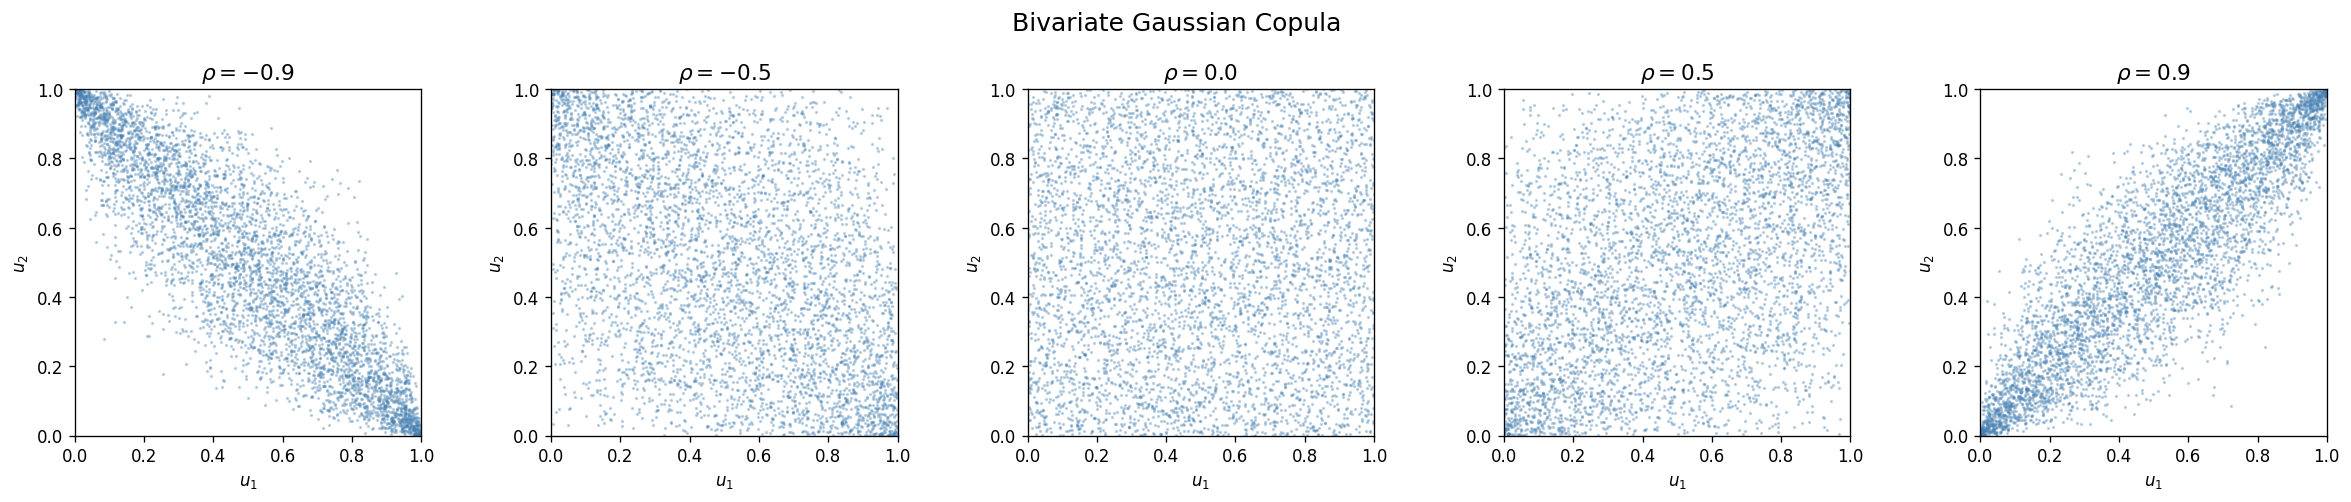

In [ ]:
def sample_t_copula(rho, nu, n=5000, seed=42):
    """
    Sample from a bivariate Student's t-copula.

    Method:
      1. Sample Z ~ N(0, Sigma)
      2. Sample S ~ chi2(nu) / nu
      3. T = Z / sqrt(S)  → bivariate t-distribution
      4. Apply PIT with t-CDF → uniform marginals
    """
    rng = np.random.default_rng(seed)
    cov = np.array([[1, rho], [rho, 1]])
    z = rng.multivariate_normal([0, 0], cov, size=n)
    s = rng.chisquare(nu, size=n) / nu
    t = z / np.sqrt(s)[:, None]
    u = stats.t.cdf(t, df=nu)
    return u[:, 0], u[:, 1]


# Vary degrees of freedom with fixed rho
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

# Row 1: Fix rho=0.5, vary nu
nus = [2, 5, 10, 50]
for ax, nu in zip(axes[0], nus):
    u1, u2 = sample_t_copula(rho=0.5, nu=nu)
    ax.scatter(u1, u2, s=1, alpha=0.3, color="darkred")
    ax.set_title(f"$\\nu = {nu}$, $\\rho = 0.5$", fontsize=12)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect("equal")

# Row 2: Fix nu=3, vary rho
rhos_t = [-0.7, 0.0, 0.5, 0.9]
for ax, rho in zip(axes[1], rhos_t):
    u1, u2 = sample_t_copula(rho=rho, nu=3)
    ax.scatter(u1, u2, s=1, alpha=0.3, color="darkred")
    ax.set_title(f"$\\nu = 3$, $\\rho = {rho}$", fontsize=12)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect("equal")

axes[0][0].set_ylabel("Fixed $\\rho$, varying $\\nu$", fontsize=12)
axes[1][0].set_ylabel("Fixed $\\nu$, varying $\\rho$", fontsize=12)
fig.suptitle("Bivariate Student's $t$-Copula", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

![Student's t-Copula](Figure_3.png)

- Effect of $\nu$: Lower $\nu$ produces heavier tails and more tail dependence. As $\nu \to \infty$, the $t$-copula converges to the Gaussian copula.
- Effect of $\rho$: Similar to the Gaussian case, higher $|\rho|$ increases overall dependence strength.
- Difference from Gaussian copula: The $t$-copula can capture joint extreme events.
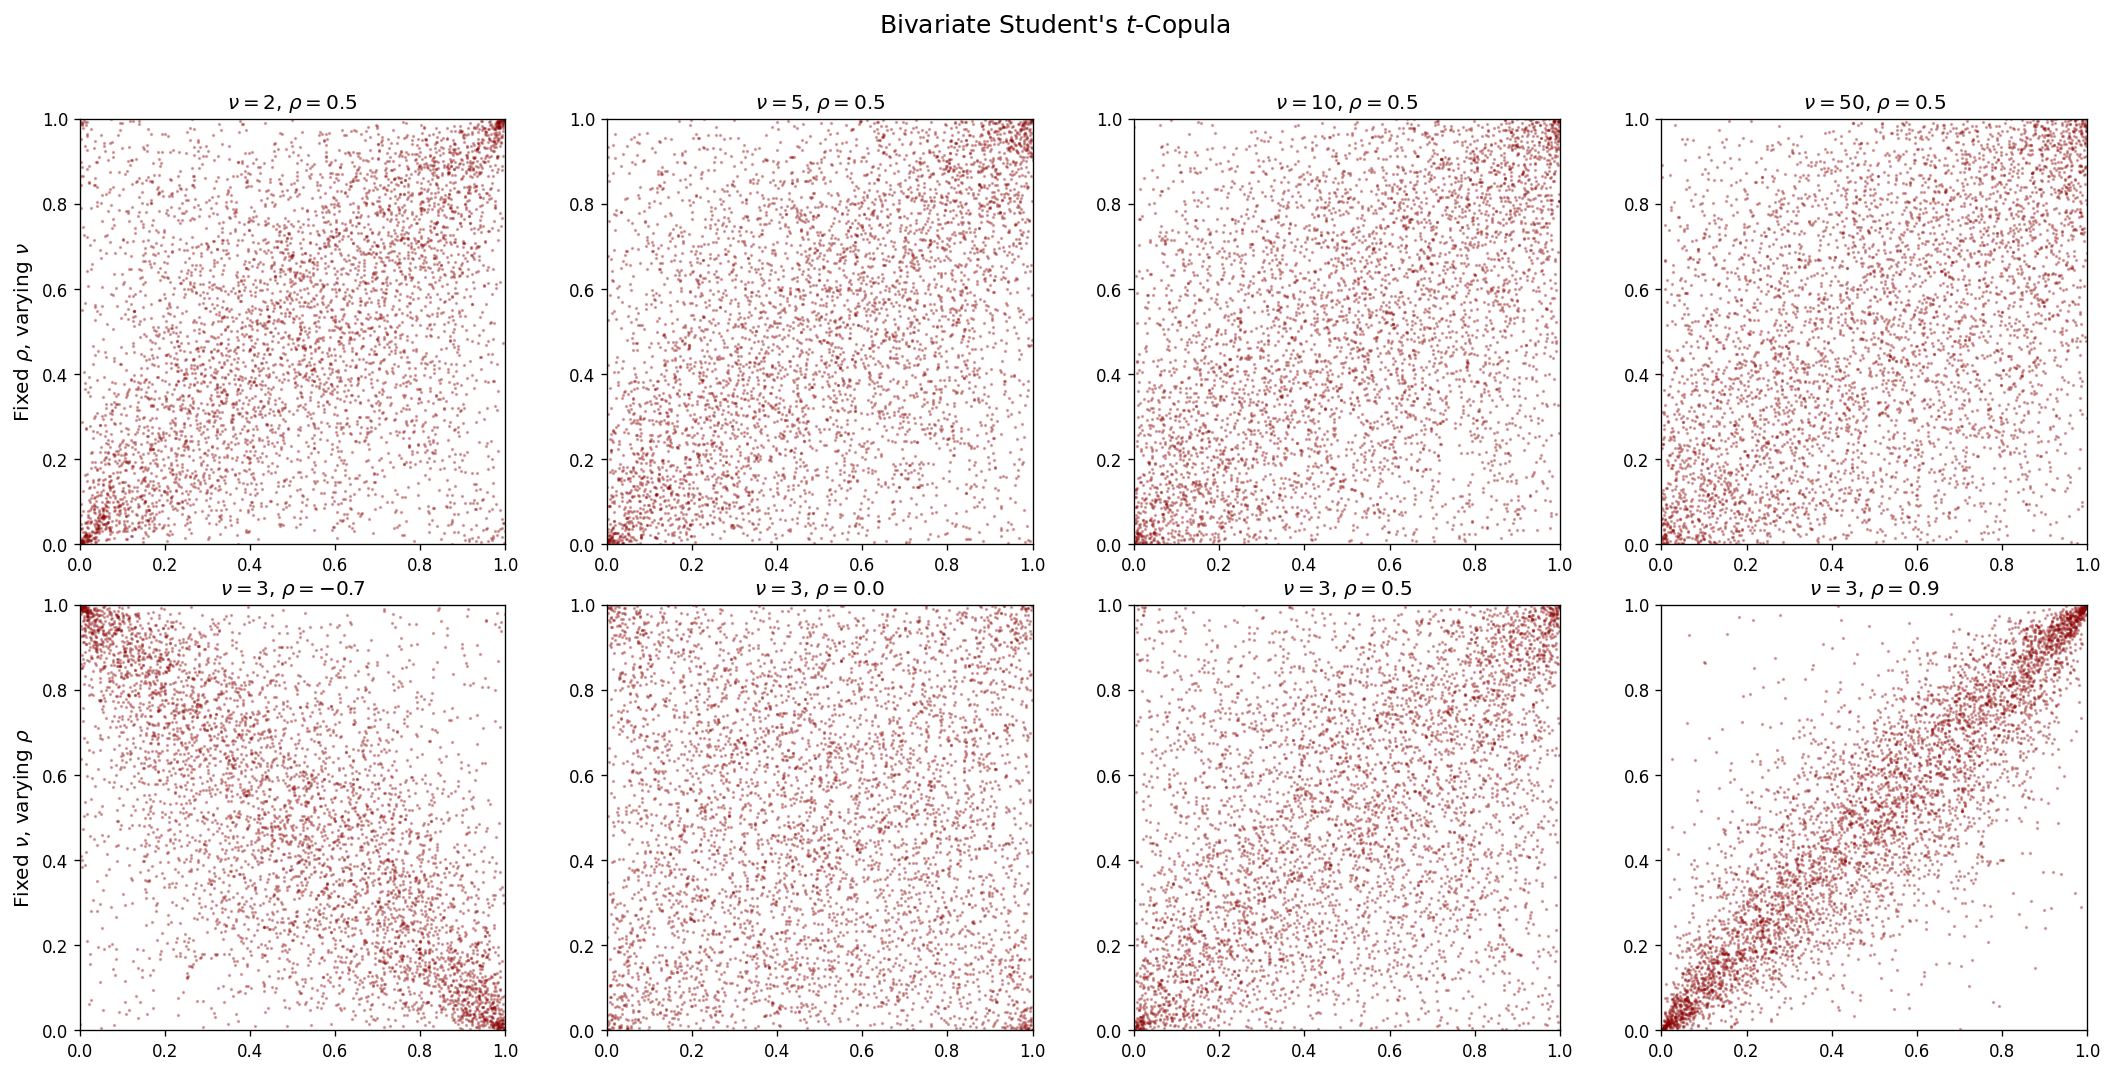

---

## Part III — Mean-Covariance Analysis

## Q6. Stock Returns Analysis

TSMC (2330.TW) and Hon Hai (2317.TW) from 2019 to 2024, downloaded via Yahoo Finance.

In [ ]:
import yfinance as yf

# Download data
symbols = ["2330.TW", "2317.TW"]
names = {"2330.TW": "TSMC", "2317.TW": "Hon Hai"}

data = yf.download(symbols, start="2019-01-01", end="2024-12-31", auto_adjust=True)
prices = data["Close"].dropna()

# Compute log-returns
log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns.columns = [names[s] for s in log_returns.columns]

print(f"Period: {log_returns.index[0].date()} — {log_returns.index[-1].date()}")
print(f"Observations: {len(log_returns)}")
print(f"\nDescriptive Statistics:")
print(log_returns.describe().T[["mean", "std", "min", "max"]])

### 6a. Mean, Covariance, and Z-scores

In [ ]:
X = log_returns.values
n_obs, d = X.shape

mu_vec    = X.mean(axis=0)
Sigma     = np.cov(X, rowvar=False)
sigma_vec = np.sqrt(np.diag(Sigma))
corr      = Sigma / np.outer(sigma_vec, sigma_vec)

# Z-scores (standardized returns)
Z_scores = (X - mu_vec) / sigma_vec

print("Mean vector μ:")
for name, m in zip(log_returns.columns, mu_vec):
    print(f"  {name}: {m:+.6f}")

print("\nCovariance matrix Σ:")
print(np.array2string(Sigma, precision=6))

print("\nCorrelation matrix:")
print(np.array2string(corr, precision=4))

print("\nZ-scores — first 5 rows:")
print(Z_scores[:5].round(3))
print(f"\nZ-scores mean (≈0): {Z_scores.mean(axis=0).round(3)}")
print(f"Z-scores std  (≈1): {Z_scores.std(axis=0, ddof=0).round(3)}")

### 6b. Spectral Decomposition (PCA) & Confidence Ellipsoid

The covariance matrix admits the spectral decomposition $\Sigma = E\,\Lambda\,E^\top$ with $\Lambda = \operatorname{diag}(\lambda_1, \lambda_2)$. The $c$-confidence ellipsoid is
$$\bigl\{ x : (x - \mu)^\top \Sigma^{-1} (x - \mu) \le \chi^2_{d}(c) \bigr\},$$
with semi-axes $\sqrt{\lambda_i \cdot \chi^2_d(c)}$ along $E_i$.

![Confidence Ellipsoid](Figure_7.png)

Spectral decomposition of $\Sigma$:

| Component | Variance $\lambda_i$ | Explained ratio | Direction $E_i$ |
| :--- | ---: | ---: | :--- |
| PC1 | $4.399 \times 10^{-4}$ | 72.4% | $(0.694,\ 0.720)$ |
| PC2 | $1.676 \times 10^{-4}$ | $27.6\%$ | $(-0.720,\ 0.694)$ |

PC1 is almost exactly the $45^\circ$ diagonal — a single "market-factor" drives most of the joint variance. PC2 is orthogonal and captures the idiosyncratic spread between the two stocks.

### 6c. Portfolio Mean & Variance ($\mathbf{w} = [0.2,\ 0.8]^\top$)

For a portfolio with weight vector $\mathbf{w}$ and asset returns $X$:
$$\mu_p = \mathbf{w}^\top \mu, \qquad \sigma_p^2 = \mathbf{w}^\top \Sigma\, \mathbf{w}$$

In [ ]:
w = np.array([0.2, 0.8])

mu_p  = w @ mu_vec
var_p = w @ Sigma @ w
std_p = np.sqrt(var_p)

print(f"Portfolio weights:  w = {w}")
print(f"Assets:             {list(log_returns.columns)}")
print(f"\nDaily portfolio statistics:")
print(f"  Mean      μ_p = {mu_p:+.6f}")
print(f"  Variance  σ_p² = {var_p:.3e}")
print(f"  Std       σ_p = {std_p:.6f}")
print(f"\nAnnualized (252 trading days):")
print(f"  Mean      = {mu_p * 252:+.4f}")
print(f"  Std       = {std_p * np.sqrt(252):.4f}")
print(f"  Sharpe-like ratio (μ/σ, daily): {mu_p / std_p:.4f}")

---

## Q7. Linear Independence and Normal Coincidence

Notation.
- $\operatorname{Cv}\{X,Z\}$: cross-covariance.
- $\perp\!\!\!\perp_{mc}$: mean-covariance (linear) independence, defined by $\operatorname{Cv}\{X,Z\}=0$.
- Best linear predictor: $\mathbb{E}\{X \parallel Z\} = \mu_X + \Sigma_{XZ}\Sigma_{ZZ}^{-1}(Z - \mu_Z)$.
- Linear conditional covariance: $\operatorname{Cv}\{X \parallel Z\} = \Sigma_{XX} - \Sigma_{XZ}\Sigma_{ZZ}^{-1}\Sigma_{ZX}$ (Schur complement, constant in $Z$).

### 7a. Affine Invariance

Claim. For nonsingular $b_X, b_Z$:
$$X \perp\!\!\!\perp_{mc} Z \iff a_X + b_X X \perp\!\!\!\perp_{mc} a_Z + b_Z Z.$$

Proof. By bilinearity and translation invariance:
$$\operatorname{Cv}\{a_X + b_X X,\ a_Z + b_Z Z\} = b_X\,\operatorname{Cv}\{X, Z\}\,b_Z^\top.$$
Since $b_X, b_Z$ are nonsingular, the RHS vanishes iff $\operatorname{Cv}\{X,Z\}=0$. $\blacksquare$

### 7b. Residual Properties

Let $\mathring{\varepsilon} \equiv X - \mathbb{E}\{X \parallel Z\} = (X - \mu_X) - \Sigma_{XZ}\Sigma_{ZZ}^{-1}(Z - \mu_Z)$.

(i) Taking expectation:
$$\mathbb{E}\{\mathring{\varepsilon}\} = (\mu_X - \mu_X) - \Sigma_{XZ}\Sigma_{ZZ}^{-1}(\mu_Z - \mu_Z) = 0. \quad\blacksquare$$

(ii) For any affine $a + bZ$, by translation invariance $\operatorname{Cv}\{\mathring{\varepsilon}, a + bZ\} = b\,\operatorname{Cv}\{\mathring{\varepsilon}, Z\}$, so it suffices to show $\operatorname{Cv}\{\mathring{\varepsilon}, Z\} = 0$:
$$\operatorname{Cv}\{\mathring{\varepsilon}, Z\}
= \operatorname{Cv}\{X, Z\} - \Sigma_{XZ}\Sigma_{ZZ}^{-1}\operatorname{Cv}\{Z,Z\}
= \Sigma_{XZ} - \Sigma_{XZ}\Sigma_{ZZ}^{-1}\Sigma_{ZZ} = 0. \quad\blacksquare$$

### 7c. Total Covariance

Claim. $\operatorname{Cv}\{X\} = \mathbb{E}\{\operatorname{Cv}\{X \parallel Z\}\} + \operatorname{Cv}\{\mathbb{E}\{X \parallel Z\}\}$.

Proof. Decompose $X = \mathbb{E}\{X \parallel Z\} + \mathring{\varepsilon}$. By (7b-ii), $\mathring{\varepsilon}$ is uncorrelated with every affine function of $Z$, including $\mathbb{E}\{X \parallel Z\}$, hence:
$$\operatorname{Cv}\{X\} = \operatorname{Cv}\{\mathbb{E}\{X \parallel Z\}\} + \operatorname{Cv}\{\mathring{\varepsilon}\}.$$

Direct computation gives $\operatorname{Cv}\{\mathring{\varepsilon}\} = \Sigma_{XX} - \Sigma_{XZ}\Sigma_{ZZ}^{-1}\Sigma_{ZX}$, which is precisely $\operatorname{Cv}\{X \parallel Z\}$. Since this is constant in $Z$, taking $\mathbb{E}\{\cdot\}$ over $Z$ leaves it unchanged:
$$\operatorname{Cv}\{\mathring{\varepsilon}\} = \mathbb{E}\{\operatorname{Cv}\{X \parallel Z\}\}.$$
Substituting back yields the claim. $\blacksquare$

### 7d. Normal Coincidence

For jointly Gaussian $(X, Z) \sim N(\mu, \Sigma)$, the conditional distribution is
$$X \mid Z = z \ \sim\ N\!\Bigl(\mu_X + \Sigma_{XZ}\Sigma_{ZZ}^{-1}(z - \mu_Z),\ \ \Sigma_{XX} - \Sigma_{XZ}\Sigma_{ZZ}^{-1}\Sigma_{ZX}\Bigr).$$

(i) Expectation. The conditional mean is affine in $Z$ — exactly the linear projection:
$$\mathbb{E}^N\{X \mid Z\} = \mu_X + \Sigma_{XZ}\Sigma_{ZZ}^{-1}(Z - \mu_Z) = \mathbb{E}^N\{X \parallel Z\}. \quad\blacksquare$$

(ii) Covariance. The conditional covariance does not depend on $z$ and equals the Schur complement:
$$\operatorname{Cv}^N\{X \mid Z\} = \Sigma_{XX} - \Sigma_{XZ}\Sigma_{ZZ}^{-1}\Sigma_{ZX} = \operatorname{Cv}^N\{X \parallel Z\}. \quad\blacksquare$$

(iii) Independence. For jointly Gaussian variables, zero covariance $\Rightarrow$ full independence. Applied to the conditional residuals (which are themselves jointly normal under Gaussianity):
- $X \perp\!\!\!\perp_{mc} Y \mid Z \Rightarrow$ residuals after partialling $Z$ are uncorrelated $\Rightarrow$ independent $\Rightarrow X \perp\!\!\!\perp Y \mid Z$.
- The reverse $X \perp\!\!\!\perp Y \mid Z \Rightarrow X \perp\!\!\!\perp_{mc} Y \mid Z$ is immediate. $\blacksquare$

> Under Gaussianity, the linear operators $\mathbb{E}\{\cdot \parallel Z\},\ \operatorname{Cv}\{\cdot \parallel Z\},\ \perp\!\!\!\perp_{mc}$ coincide with the conditional operators $\mathbb{E}\{\cdot \mid Z\},\ \operatorname{Cv}\{\cdot \mid Z\},\ \perp\!\!\!\perp$.

---

## Q8. Projection & Residuals (Partial Uncorrelation)

We reproduce the non-linear construction from Section 6.3 to illustrate partial uncorrelation: two variables $X_1, X_2$ that look strongly correlated become uncorrelated once we project out a shared anchor $Z$.

Setup. Let $\varepsilon_1, \varepsilon_2, \varepsilon_3 \stackrel{\text{iid}}{\sim} N(0, 1)$ and define

$$\begin{aligned}
X_1 &\equiv \varepsilon_1 + \tfrac{1}{5}\varepsilon_2 + \cos \varepsilon_2 + \tfrac{1}{5}\varepsilon_3^3, \\
X_2 &\equiv \tfrac{1}{5}\varepsilon_2 + \tfrac{(e-1)^2}{6 e^2}\varepsilon_3 - \cos \varepsilon_2 + \tfrac{1}{5}\varepsilon_3^3, \\
Z   &\equiv 1 - \tfrac{2}{3}(\varepsilon_2 + \varepsilon_3^3).
\end{aligned}$$

Analytical linear projections give $\mathbb{E}\{X_i \parallel Z\} = \alpha_i + \beta Z$ with
$$\alpha_1 = \tfrac{3}{10} + e^{-1/2},\quad \alpha_2 = \tfrac{3}{10} - e^{-1/2},\quad \beta = -\tfrac{3}{10},$$

and residuals
$$\eta_1 = \varepsilon_1 + \cos\varepsilon_2 - e^{-1/2}, \qquad \eta_2 = \tfrac{(e-1)^2}{6 e^2}\varepsilon_3 - \cos\varepsilon_2 + e^{-1/2}.$$

Claim. Although $X_1$ and $X_2$ are strongly dependent, the residuals satisfy $\eta_1 \perp\!\!\!\perp_{mc} \eta_2$, i.e. $X_1 \perp\!\!\!\perp_{mc} X_2 \parallel Z$. We verify this by Monte Carlo.

![Partial Uncorrelation](Figure_8.png)

`$\eta_1 \perp\!\!\!\perp_{mc} \eta_2$ does not hold?`

Linear projection coefficients (theory vs 20 000 Monte Carlo samples):

| Coefficient | Theory | Empirical |
| :--- | ---: | ---: |
| $\alpha_1$ | $+0.9065$ | $+0.8979$ |
| $\alpha_2$ | $-0.3065$ | $-0.2876$ |
| $\beta_1$  | $-0.3000$ | $-0.2970$ |
| $\beta_2$  | $-0.3000$ | $-0.3195$ |

Correlation diagnostics:

| Quantity | Value | Comment |
| :--- | ---: | :--- |
| $\operatorname{Corr}(X_1, X_2)$ | $+0.359$ | raw dependence |
| $\operatorname{Corr}(\eta_1, \eta_2)$ | $-0.406$ | partial correlation |
| $\operatorname{Corr}(\eta_1, Z)$ | $\approx 0$ | projection orthogonality |
| $\operatorname{Corr}(\eta_2, Z)$ | $\approx 0$ | projection orthogonality |


---

## Part IV — Empirical Analysis

## Q9. Dataset Evaluation

### 9a. Probability Density — Empirical vs. Gaussian

![Empirical vs Gaussian](Figure_4.png)

Daily log-return descriptive statistics:

| Asset | mean | std | min | max |
| :--- | ---: | ---: | ---: | ---: |
| Hon Hai | +0.000846 | 0.017287 | −0.1050 | +0.0947 |
| TSMC    | +0.001207 | 0.017570 | −0.1025 | +0.0951 |

The fitted Gaussian curve misses the sharp peak at zero and under-represents the large negative / positive excursions — a first visual symptom of heavy tails.

### 9b. Stylized Facts — Heavy Tails & Skewness

In [ ]:
from scipy.stats import jarque_bera, kurtosis, skew

print("Stylized Facts Analysis")
print("=" * 60)

for col in log_returns.columns:
    r = log_returns[col].dropna()
    s = skew(r)
    k = kurtosis(r, fisher=True)  # excess kurtosis (Gaussian = 0)
    jb_stat, jb_pval = jarque_bera(r)

    print(f"\n{col}:")
    print(f"  Skewness:        {s:+.4f}  {'(negative → left-skewed)' if s < 0 else '(positive → right-skewed)'}")
    print(f"  Excess Kurtosis: {k:+.4f}  {'(> 0 → HEAVY TAILS)' if k > 0 else '(≤ 0 → thin tails)'}")
    print(f"  Jarque-Bera:     {jb_stat:.2f}  (p = {jb_pval:.2e})")
    print(f"  → {'Reject normality (p < 0.05)' if jb_pval < 0.05 else 'Cannot reject normality'}")

print("\n" + "=" * 60)
print("Conclusion: Both series exhibit heavy tails (excess kurtosis >> 0)")
print("and the Jarque-Bera test strongly rejects normality.")

### 9c. Q-Q Plots

![Q-Q Plot](Figure_5.png)

Q-Q Plot Interpretation:

- If the data were normal, all points would lie on the red reference line.
- The S-shaped deviation in the tails (points below the line on the left, above on the right) confirms heavy tails, extreme returns occur more frequently than a Gaussian model predicts.

### 9d. Copula Application — Dependence Structure

![Copula Analysis](Figure_6.png)

Dependence measures (TSMC vs Hon Hai):

| Measure | Value |
| :--- | ---: |
| Pearson $\rho$ | $+0.4479$ |
| Spearman $\rho_S$ | $+0.4490$ |
| Kendall $\tau$ | $+0.3172$ |
| Joint lower tail (both $u_i < 0.10$) | 68 pts |
| Joint upper tail (both $u_i > 0.90$) | 42 pts |
| Expected per corner under independence | $\approx 15$ pts |

The joint lower tail contains $\sim 4.5\times$ the mass expected under independence — clear evidence of lower tail dependence, consistent with the empirical fact that Taiwan tech stocks crash together.

### 9e. Advanced Visualization — Linear Projection on the Dataset

Applying the Mean-Covariance class to the TSMC / Hon Hai returns, we compute the best linear predictor
$$\mathbb{E}\{\text{TSMC} \parallel \text{Hon Hai}\} = \mu_X + \frac{\operatorname{Cv}\{X, Z\}}{\operatorname{Var}\{Z\}} (Z - \mu_Z)$$
and its residual $\mathring{\varepsilon} = X - \hat X$.

![Linear Projection on Dataset](Figure_9.png)

Projection diagnostics:

| Quantity | Value |
| :--- | ---: |
| $\alpha$ (intercept) | $+0.000822$ |
| $\beta$ (slope) | $+0.4553$ |
| Residual mean $\bar{\varepsilon}$ | $\approx 0$ |
| $\operatorname{Cov}(\varepsilon, Z)$ | $\approx 0$ |
| Residual std $\sigma_\varepsilon$ | $0.01571$ |
| $R^2 = 1 - \sigma_\varepsilon^2 / \sigma_X^2$ | $0.2006$ |

The linear predictor explains only $\sim 20\%$ of TSMC's daily log-return variance — the remaining $\sim 80\%$ sits in the idiosyncratic residual. The residual histogram retains the heavy-tailed character seen in 9a–9c: linear projection removes the common market component but does not normalize the return distribution.

Copula Analysis Summary:

1. Positive dependence: Pearson, Spearman, and Kendall correlations are all positive, indicating that TSMC and Hon Hai tend to move together.

2. Empirical copula shape: The copula scatter (middle panel) shows concentration along the diagonal, consistent with positive dependence. There appears to be slightly more mass in the lower-left corner than upper-right, not perfectly symmetric.

3. Tail dependence: The number of observations in the joint lower tail exceeds what we would expect under independence, suggesting lower tail dependence. Stocks are more correlated during crashes than during rallies.

4. Copula model choice: Given the observed tail dependence, a Student's $t$-copula would be more appropriate than a Gaussian copula for modelling this pair, as the Gaussian copula has zero tail dependence coefficient.